In [1]:
!pip install pytorch-lightning timm
import os
import random
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance, ImageOps
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from glob import glob
import cv2
from pytorch_lightning.callbacks import TQDMProgressBar
from pytorch_lightning.loggers import TensorBoardLogger

import torch
import torchvision.transforms as T
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

os.environ['KAGGLE_USERNAME'] = "birvika"
os.environ['KAGGLE_KEY'] = "15d2dbff346b377b89dab3f99d4fadd4"
import kagglehub

dataset_path = kagglehub.competition_download('dl-lab-4-ocr')
train_dir = os.path.join(dataset_path, 'train/train')
test_dir = os.path.join(dataset_path, 'test/test')
train_df = pd.read_csv(os.path.join(dataset_path, 'train.csv'))

device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 9999
pl.seed_everything(seed)


from google.colab import drive
drive.mount("/content/drive")


font_path = '/content/drive/MyDrive/5ka-sans-design/5kaSansDesign-Ultra.ttf'
if not os.path.exists(font_path):
    font_path = '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf'
print("Font:", font_path)


BACKGROUNDS_FOLDER = '/content/drive/MyDrive/фоны'
backgrounds = []
if os.path.exists(BACKGROUNDS_FOLDER):
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        for f in glob(os.path.join(BACKGROUNDS_FOLDER, ext)):
            img = cv2.imread(f)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                backgrounds.append(img)
    print(f"Loaded {len(backgrounds)} backgrounds")

if not backgrounds:
    for _ in range(50):
        color = tuple(random.randint(200, 255) for _ in range(3))
        backgrounds.append(np.full((128, 32, 3), color, dtype=np.uint8))


def clean_text(text):

    text = ''.join([c for c in str(text) if c.isdigit()])
    return text if text != "" else "0"

def add_white_stripes(img, p=0.12):

    if random.random() > p:
        return img

    img_array = np.array(img).astype(np.float32)
    h, w = img_array.shape[:2]


    if random.choice(['stripe', 'stripe', 'spot']) == 'stripe':

        if random.choice(['horizontal', 'vertical']) == 'horizontal':
            y = random.randint(0, h - 1)
            thickness = random.randint(2, 5)
            y_start = max(0, y - thickness // 2)
            y_end = min(h, y + thickness // 2)
            img_array[y_start:y_end, :] = 255
        else:
            x = random.randint(0, w - 1)
            thickness = random.randint(2, 5)
            x_start = max(0, x - thickness // 2)
            x_end = min(w, x + thickness // 2)
            img_array[:, x_start:x_end] = 255
    else:

        cx = random.randint(0, w - 1)
        cy = random.randint(0, h - 1)
        radius = random.randint(5, 12)
        Y, X = np.ogrid[:h, :w]
        mask = (X - cx) ** 2 + (Y - cy) ** 2 <= radius ** 2
        img_array[mask] = np.clip(img_array[mask] * 1.5, 0, 255)

    return Image.fromarray(img_array.astype(np.uint8))

def generate_synthetic():

    img_w, img_h = 128, 64
    bg = random.choice(backgrounds).copy()
    bg = cv2.resize(bg, (img_w, img_h))
    img = Image.fromarray(bg)
    draw = ImageDraw.Draw(img)


    num_digits = random.choices([1, 2, 3, 4, 5], weights=[5, 10, 20, 50, 10], k=1)[0]

    if num_digits == 1:
        price = str(random.randint(1, 9))
        font_size = random.randint(38, 48)
    elif num_digits == 2:
        price = str(random.randint(10, 99))
        font_size = random.randint(34, 44)
    elif num_digits == 3:
        price = str(random.randint(100, 999))
        font_size = random.randint(30, 40)
    elif num_digits == 4:
        price = str(random.randint(1000, 9999))
        font_size = random.randint(26, 36)
    elif num_digits == 5:
        price = str(random.randint(10000, 99999))
        font_size = random.randint(22, 30)

    try:
        font = ImageFont.truetype(font_path, font_size)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), price, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]
    x = (img_w - text_w) // 2 + random.randint(-5, 5)
    y = (img_h - text_h) // 2 + random.randint(-5, 5)
    draw.text((x, y), price, fill=(0, 0, 0), font=font)

    return img, price, (0, 0, 0)

def degrade(img, bg_color):

    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    if random.random() < 0.5:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))

    if random.random() < 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))
    return img


from torch.utils.data import DataLoader

parseq_transform = T.Compose([
    T.Resize((32, 128), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

class PARSeqDataset(torch.utils.data.Dataset):
    def __init__(self, df, root_dir, num_synthetic=6000):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.num_synthetic = num_synthetic

    def __len__(self):
        return len(self.df) + self.num_synthetic

    def __getitem__(self, idx):

        if idx < len(self.df):
            filename = self.df.iloc[idx]['Filename']
            price = clean_text(self.df.iloc[idx]['Price'])
            image = Image.open(os.path.join(self.root_dir, filename)).convert("RGB")
            image = ImageOps.autocontrast(image)
            if random.random() < 0.3:
                image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
        # Синтетика
        else:
            image, price, bg_color = generate_synthetic()
            image = degrade(image, bg_color)

            # Добавляем белые полосы/засветы (редко, ~12% синтетики)
            image = add_white_stripes(image, p=0.12)

            if random.random() < 0.8:
                w_sm, h_sm = random.randint(20, 40), random.randint(10, 20)
                image = image.resize((w_sm, h_sm), Image.BILINEAR)

        image = image.resize((128, 64), Image.BICUBIC)
        image_tensor = parseq_transform(image)
        return {"image": image_tensor, "label": price}

def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    labels = [item["label"] for item in batch]
    return images, labels


train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

train_dataset = PARSeqDataset(train_df, train_dir, num_synthetic=7000)
val_dataset = PARSeqDataset(val_df, train_dir, num_synthetic=0)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.3 MB/s eta 0:00:00


100%|██████████| 19.6M/19.6M [00:01<00:00, 10.5MB/s]

Extracting files...



INFO:lightning_fabric.utilities.seed:Seed set to 9999


Mounted at /content/drive
Font: /content/drive/MyDrive/5ka-sans-design/5kaSansDesign-Ultra.ttf
Loaded 20 backgrounds
Train batches: 298, Val batches: 48
Train samples: 19040, Val samples: 3010


In [2]:

sample = train_dataset[0]
print(f"Тип: {type(sample)}")
print(f"Ключи: {sample.keys() if isinstance(sample, dict) else 'Not a dict'}")
print(f"Значение: {sample}")

idx = len(train_df) + 1
sample_synth = train_dataset[idx]
print(f"\nСинтетический пример: {sample_synth}")

Тип: <class 'dict'>
Ключи: dict_keys(['image', 'label'])
Значение: {'image': tensor([[[0.8745, 0.8667, 0.8510,  ..., 0.7176, 0.7020, 0.6941],
         [0.8353, 0.8353, 0.8196,  ..., 0.7490, 0.7333, 0.7176],
         [0.7804, 0.7804, 0.7647,  ..., 0.7725, 0.7569, 0.7490],
         ...,
         [0.7725, 0.7647, 0.7569,  ..., 0.7098, 0.7255, 0.7255],
         [0.7098, 0.7098, 0.7098,  ..., 0.7255, 0.7255, 0.7255],
         [0.6471, 0.6471, 0.6471,  ..., 0.6941, 0.7020, 0.7020]],

        [[1.0000, 1.0000, 0.9843,  ..., 0.8588, 0.8510, 0.8510],
         [0.9765, 0.9765, 0.9608,  ..., 0.8980, 0.8902, 0.8902],
         [0.9294, 0.9294, 0.9216,  ..., 0.9294, 0.9216, 0.9216],
         ...,
         [0.9765, 0.9765, 0.9686,  ..., 0.8039, 0.8275, 0.8275],
         [0.9373, 0.9373, 0.9294,  ..., 0.8118, 0.8275, 0.8353],
         [0.8824, 0.8824, 0.8745,  ..., 0.7804, 0.7961, 0.8039]],

        [[1.0000, 1.0000, 0.9922,  ..., 0.9294, 0.9216, 0.9216],
         [0.9686, 0.9686, 0.9608,  ..., 0.9686

In [3]:
model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True)
model = model.to(device)
model.hparams.lr = 4e-5


import os
save_dir = '/content/drive/MyDrive/laba_go_4/'


if not os.path.exists('/content/drive'):

    from google.colab import drive
    drive.mount('/content/drive')


os.makedirs(save_dir, exist_ok=True)
print(f" Папка создана: {save_dir}")


if os.access(save_dir, os.W_OK):
    print(" Есть права на запись в папку")
else:
    print(" Нет прав на запись в папку!")

checkpoint_callback = ModelCheckpoint(
    dirpath=save_dir,
    filename='parseq_best',
    monitor='val_accuracy',
    mode='max',
    save_top_k=1,
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    mode='max',
    verbose=True,
    min_delta=0.001,
)


from torch.optim.lr_scheduler import ReduceLROnPlateau


class PARSeqLightningWithScheduler(pl.LightningModule):
    def __init__(self, model, lr=4e-5):
        super().__init__()
        self.model = model
        self.lr = lr
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        logits = self.model(images)
        # Здесь нужна ваша логика loss
        loss = F.cross_entropy(logits, labels)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self.model(images)
        loss = F.cross_entropy(logits, labels)
        preds = logits.argmax(dim=-1)
        acc = (preds == labels).float().mean()
        self.log('val_loss', loss)
        self.log('val_accuracy', acc)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=2,
            verbose=True
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_accuracy',
                'frequency': 1
            }
        }

from pytorch_lightning.callbacks import Callback

class LRSchedulerCallback(Callback):
    def __init__(self, patience=2, factor=0.5):
        self.patience = patience
        self.factor = factor
        self.best_acc = 0
        self.counter = 0

    def on_validation_epoch_end(self, trainer, pl_module):
        current_acc = trainer.callback_metrics.get('val_accuracy', 0)
        if isinstance(current_acc, torch.Tensor):
            current_acc = current_acc.item()

        if current_acc > self.best_acc:
            self.best_acc = current_acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                old_lr = trainer.optimizers[0].param_groups[0]['lr']
                new_lr = old_lr * self.factor
                for param_group in trainer.optimizers[0].param_groups:
                    param_group['lr'] = new_lr
                print(f"\n📉 Уменьшен LR: {old_lr:.2e} -> {new_lr:.2e}")
                self.counter = 0

logger = TensorBoardLogger("lightning_logs", name="parseq")


if torch.cuda.is_available():
    trainer = pl.Trainer(
        max_epochs=30,
        accelerator='gpu',
        devices=1,
        callbacks=[
            checkpoint_callback,
            early_stop,
            LRSchedulerCallback(patience=2, factor=0.5),
            TQDMProgressBar(refresh_rate=10)
        ],
        enable_model_summary=False
    )
else:
    trainer = pl.Trainer(
        max_epochs=30,
        accelerator='cpu',
        callbacks=[
            checkpoint_callback,
            early_stop,
            LRSchedulerCallback(patience=2, factor=0.5),
            TQDMProgressBar(refresh_rate=10)
        ],
        enable_model_summary=False
    )

print(f"Learning rate: {model.hparams.lr}")
print("Early Stopping: остановка если 3 эпохи без улучшения")
print("LR Scheduler: уменьшение LR в 2 раза если 2 эпохи без улучшений")
print(f"Модель сохраняется в: {save_dir}")

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)


print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ")
print("="*50)

if early_stop.stopped_epoch > 0:
    print(f"Early Stopping сработал на эпохе {early_stop.stopped_epoch}")
    print(f" Лучшая val_accuracy: {early_stop.best_score:.4f} ({early_stop.best_score*100:.2f}%)")
else:
    print(f" Обучение завершило все {trainer.current_epoch} эпох")
    print(f" Лучшая val_accuracy: {early_stop.best_score:.4f} ({early_stop.best_score*100:.2f}%)")

best_model_path = checkpoint_callback.best_model_path
print(f" Лучшая модель сохранена: {best_model_path}")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to /root/.cache/torch/hub/checkpoints/parseq-bb5792a6.pt


100%|██████████| 91.0M/91.0M [00:02<00:00, 32.7MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Validation: |          | 0/? [00:00<?, ?it/s]


📉 Уменьшен LR: 1.02e-03 -> 5.12e-04


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 4 records. Best score: 99.668. Signaling Trainer to stop.



РЕЗУЛЬТАТЫ ОБУЧЕНИЯ
Early Stopping сработал на эпохе 5
 Лучшая val_accuracy: 99.6678 (9966.78%)
 Лучшая модель сохранена: /content/drive/MyDrive/laba_go_4/parseq_best.ckpt


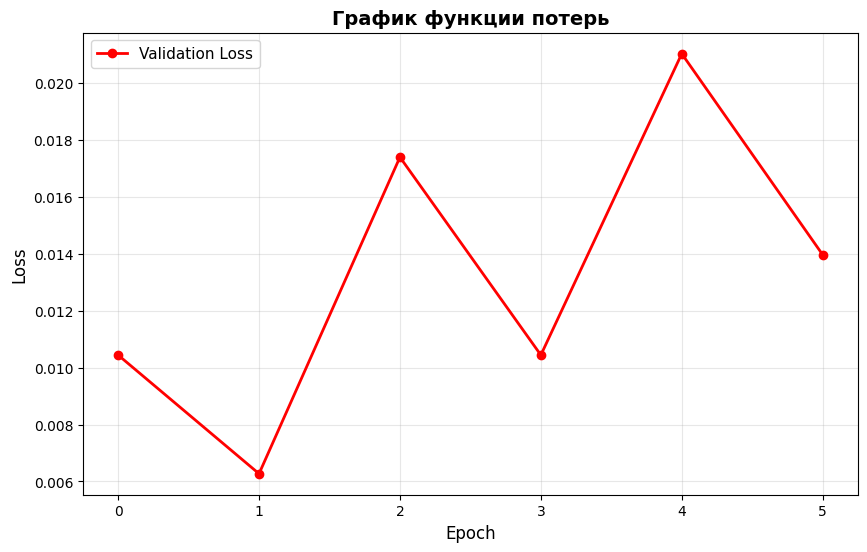

✅ График потерь сохранен: /content/drive/MyDrive/laba_go_4/loss_plot.png


In [4]:


import matplotlib.pyplot as plt
from collections import defaultdict

def extract_metrics_from_logs(logdir='lightning_logs/'):

    from tensorboard.backend.event_processing import event_accumulator

    metrics = defaultdict(list)


    versions = []
    if os.path.exists(logdir):
        for v in os.listdir(logdir):
            if v.startswith('version_'):
                versions.append(v)

    if not versions:
        print("Логи не найдены")
        return metrics

    latest_version = sorted(versions)[-1]
    log_path = os.path.join(logdir, latest_version)

    ea = event_accumulator.EventAccumulator(log_path)
    ea.Reload()


    for tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        for event in events:
            metrics[tag].append(event.value)

    return metrics

metrics = extract_metrics_from_logs('lightning_logs/')


plt.figure(figsize=(10, 6))

if 'val_loss' in metrics:
    plt.plot(metrics['val_loss'], 'r-o', linewidth=2, label='Validation Loss')
if 'train_loss' in metrics:
    plt.plot(metrics['train_loss'], 'orange-o', linewidth=2, label='Train Loss')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('График функции потерь', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.savefig(os.path.join(save_dir, 'loss_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ График потерь сохранен: {os.path.join(save_dir, 'loss_plot.png')}")

In [5]:
from collections import Counter
import os
import torch
from tqdm import tqdm
import pandas as pd
from PIL import Image, ImageFilter


import glob
ckpt_files = glob.glob("/content/drive/MyDrive/laba_go_4/*.ckpt")
if ckpt_files:
    checkpoint_path = ckpt_files[0]
    print(f"Найден чекпоинт: {checkpoint_path}")


if not os.path.exists(checkpoint_path):
    print(f" Файл не найден: {checkpoint_path}")
    print("Проверьте путь к модели!")
else:
    print(f" Загружаем модель: {checkpoint_path}")



checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()
print(" Модель загружена")


if 'dataset_path' not in dir():
    import kagglehub
    dataset_path = kagglehub.competition_download('dl-lab-4-ocr')
    print(f"dataset_path: {dataset_path}")

test_dir = os.path.join(dataset_path, 'test/test')
submission_path = os.path.join(dataset_path, 'sample_submission.csv')  # или 'submission.csv'

submission = pd.read_csv(submission_path)
print(f" Загружено {len(submission)} тестовых изображений")



def predict_parseq_tta(image, model, device):
    variants = [
        image,
        image.filter(ImageFilter.GaussianBlur(0.4))
    ]

    batch = torch.stack([parseq_transform(img) for img in variants]).to(device)

    with torch.no_grad():
        logits = model(batch)
        preds = logits.softmax(-1)
        texts, _ = model.tokenizer.decode(preds)

    texts = [clean_text(t) for t in texts]

    if all(t == "" for t in texts):
        return "0"

    return Counter(texts).most_common(1)[0][0]


pred_labels = []

for filename in tqdm(submission["Filename"]):
    image_path = os.path.join(test_dir, filename)
    image = Image.open(image_path).convert("RGB")

    pred = predict_parseq_tta(image, model, device)
    pred_labels.append(pred)



save_dir = '/content/drive/MyDrive/laba_go_4/'
os.makedirs(save_dir, exist_ok=True)

submission["Price"] = pred_labels
submission_save_path = os.path.join(save_dir, 'submission_parseq.csv')
submission.to_csv(submission_save_path, index=False)
print(f"\n Сабмишн сохранен: {submission_save_path}")




for i in range(min(10, len(pred_labels))):
    print(f"   {submission['Filename'].iloc[i]}: {pred_labels[i]}")


pred_counter = Counter(pred_labels)
print(f"\n Статистика предсказаний:")
print(f"   Уникальных значений: {len(pred_counter)}")
print(f"   Наиболее частые:")
for value, count in pred_counter.most_common(5):
    print(f"     {value}: {count} ({count/len(pred_labels)*100:.1f}%)")



Найден чекпоинт: /content/drive/MyDrive/laba_go_4/parseq_best.ckpt
 Загружаем модель: /content/drive/MyDrive/laba_go_4/parseq_best.ckpt
 Модель загружена
 Загружено 3762 тестовых изображений


100%|██████████| 3762/3762 [01:17<00:00, 48.48it/s]


 Сабмишн сохранен: /content/drive/MyDrive/laba_go_4/submission_parseq.csv
   8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg: 34
   12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg: 129
   9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg: 109
   15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg: 199
   28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg: 89
   7_D0-CF-13-23-CC-E8_2026-01-22-14-00-13.jpg: 85
   22_D0-CF-13-22-59-C8_2026-01-22-22-04-31.jpg: 129
   0_10-B4-1D-C8-01-E0_36_2025-11-15-10-59-36.jpg: 99
   9_D0-CF-13-23-6F-E8_2026-01-22-17-58-19.jpg: 81
   60_D0-CF-13-23-CD-38_2026-01-22-14-02-39.jpg: 614

 Статистика предсказаний:
   Уникальных значений: 358
   Наиболее частые:
     109: 291 (7.7%)
     199: 192 (5.1%)
     189: 166 (4.4%)
     139: 160 (4.3%)
     32: 115 (3.1%)


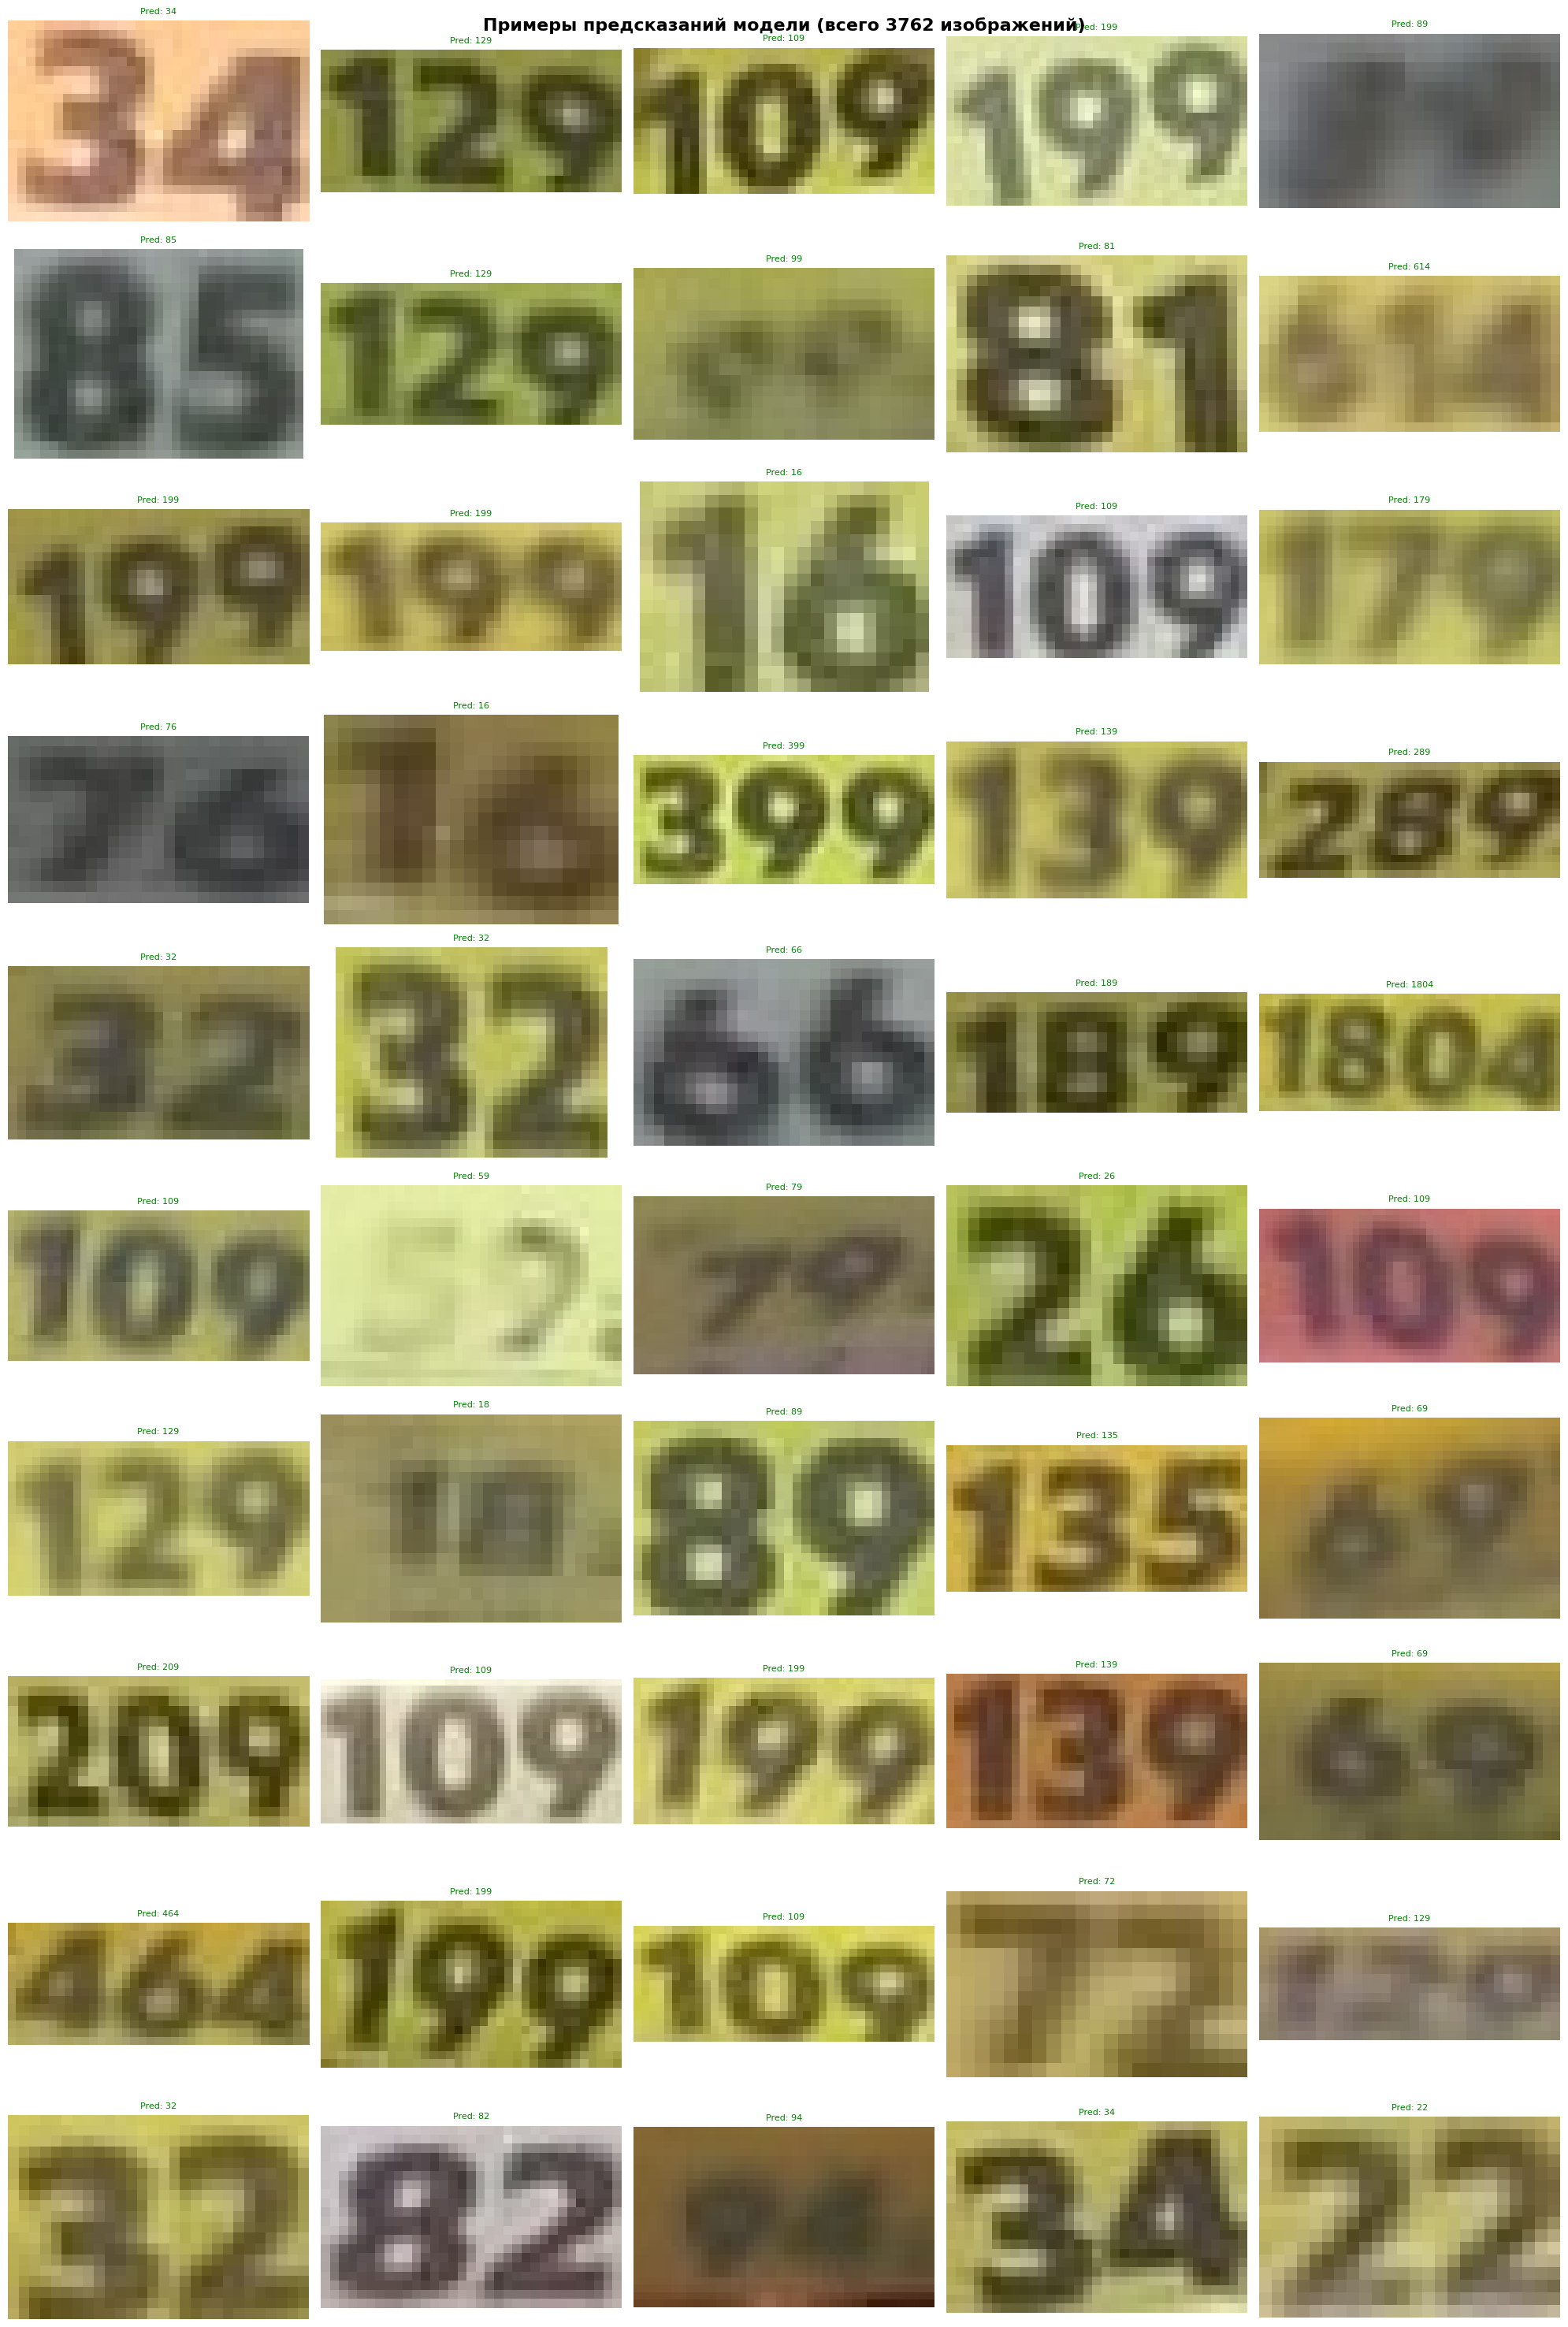

Сохранено: /content/drive/MyDrive/laba_go_4/predictions_50_examples.png


In [6]:
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import random




num_samples = min(50, len(submission))
indices = list(range(num_samples))

rows, cols = 10, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 30))
axes = axes.flatten()

for i, idx in enumerate(indices):
    if i >= num_samples:
        break

    filename = submission['Filename'].iloc[idx]
    image_path = os.path.join(test_dir, filename)
    image = Image.open(image_path).convert("RGB")


    pred = pred_labels[idx]


    axes[i].imshow(image)
    axes[i].set_title(f"Pred: {pred}", fontsize=8, color='green')
    axes[i].axis('off')


for i in range(num_samples, len(axes)):
    axes[i].axis('off')

plt.suptitle(f"Примеры предсказаний модели (всего {len(pred_labels)} изображений)",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'predictions_50_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Сохранено: {os.path.join(save_dir, 'predictions_50_examples.png')}")

In [7]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# ============================================
# СОХРАНЕНИЕ ВСЕЙ СИНТЕТИКИ НА ДИСК
# ============================================

save_dir = '/content/drive/MyDrive/laba_go_4/'
synth_images_dir = os.path.join(save_dir, 'synthetic_images')
os.makedirs(synth_images_dir, exist_ok=True)

print(f"📁 Папка для синтетики: {synth_images_dir}")
print(f"📊 Всего синтетических изображений: {train_dataset.num_synthetic}")
print(f"🎨 Начинаем сохранение...")

# Сохраняем ВСЕ синтетические изображения
def save_all_synthetic(dataset, output_dir):
    """Сохраняет все синтетические изображения из датасета"""

    real_count = len(dataset.df) if hasattr(dataset, 'df') else 0

    # Создаем список меток для отслеживания прогресса
    print(f"Реальных изображений: {real_count}")
    print(f"Синтетических: {dataset.num_synthetic}")

    saved_count = 0
    failed_count = 0

    for idx in tqdm(range(real_count, real_count + dataset.num_synthetic), desc="Сохранение синтетики"):
        try:
            item = dataset[idx]
            image_tensor = item['image']
            label = item['label']

            # Конвертируем тензор в изображение
            img = image_tensor.permute(1, 2, 0).cpu().numpy()
            img = img * 0.5 + 0.5  # Денормализация (было Normalize(0.5,0.5))
            img = np.clip(img, 0, 1)
            img = (img * 255).astype(np.uint8)

            # Сохраняем с понятным именем
            filename = f"synthetic_{saved_count:05d}_price_{label}.png"
            img_pil = Image.fromarray(img)
            img_pil.save(os.path.join(output_dir, filename))
            saved_count += 1

        except Exception as e:
            failed_count += 1
            print(f"Ошибка при сохранении индекса {idx}: {e}")

    print(f"\n✅ Сохранено {saved_count} синтетических изображений")
    print(f"❌ Ошибок: {failed_count}")
    print(f"📁 Путь: {output_dir}")

# Запускаем сохранение ВСЕЙ синтетики
save_all_synthetic(train_dataset, synth_images_dir)

# ============================================
# ДОПОЛНИТЕЛЬНО: сохранение примеров для проверки
# ============================================

# Сохраняем также несколько примеров в отдельную папку для быстрого просмотра
preview_dir = os.path.join(save_dir, 'synthetic_preview')
os.makedirs(preview_dir, exist_ok=True)

def save_preview_images(dataset, num_samples=100, output_dir=preview_dir):
    """Сохраняет несколько синтетических примеров для предпросмотра"""

    real_count = len(dataset.df) if hasattr(dataset, 'df') else 0

    for i in tqdm(range(min(num_samples, dataset.num_synthetic)), desc="Сохранение превью"):
        idx = real_count + i
        item = dataset[idx]

        img = item['image'].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        img_pil = Image.fromarray(img)
        filename = f"preview_{i:04d}_price_{item['label']}.png"
        img_pil.save(os.path.join(output_dir, filename))

    print(f"✅ Сохранено {num_samples} примеров в {output_dir}")

# Сохраняем 100 примеров для быстрого просмотра
save_preview_images(train_dataset, num_samples=100)

# ============================================
# ДОПОЛНИТЕЛЬНО: информация о сохраненных файлах
# ============================================

print("\n" + "="*50)
print("СТАТИСТИКА СОХРАНЕНИЯ")
print("="*50)

# Подсчитываем количество сохраненных файлов
import glob
synth_files = glob.glob(os.path.join(synth_images_dir, "*.png"))
preview_files = glob.glob(os.path.join(preview_dir, "*.png"))

print(f"📁 {synth_images_dir}: {len(synth_files)} файлов")
print(f"📁 {preview_dir}: {len(preview_files)} файлов")
print(f"💾 Общий размер: ~{len(synth_files) * 50 / 1024:.1f} MB")

# Показываем примеры имен файлов
if synth_files:
    print(f"\n📋 Примеры имен файлов:")
    for f in synth_files[:5]:
        print(f"   {os.path.basename(f)}")

📁 Папка для синтетики: /content/drive/MyDrive/laba_go_4/synthetic_images
📊 Всего синтетических изображений: 7000
🎨 Начинаем сохранение...
Реальных изображений: 12040
Синтетических: 7000


Сохранение синтетики: 100%|██████████| 7000/7000 [01:39<00:00, 70.36it/s]



✅ Сохранено 7000 синтетических изображений
❌ Ошибок: 0
📁 Путь: /content/drive/MyDrive/laba_go_4/synthetic_images


Сохранение превью: 100%|██████████| 100/100 [00:01<00:00, 63.39it/s]

✅ Сохранено 100 примеров в /content/drive/MyDrive/laba_go_4/synthetic_preview

СТАТИСТИКА СОХРАНЕНИЯ
📁 /content/drive/MyDrive/laba_go_4/synthetic_images: 7000 файлов
📁 /content/drive/MyDrive/laba_go_4/synthetic_preview: 100 файлов
💾 Общий размер: ~341.8 MB

📋 Примеры имен файлов:
   synthetic_00000_price_72063.png
   synthetic_00001_price_9.png
   synthetic_00002_price_636.png
   synthetic_00003_price_839.png
   synthetic_00004_price_2261.png
